## Problem Statement

### Context:

To minimize loss from the bank’s perspective, the bank needs a decision rule regarding whom to approve the loan and whom not to. An applicant’s demographic and socio-economic profiles are considered by loan managers before a decision is taken regarding his/her loan application.
In this dataset, each entry represents a person who takes credit from a bank. Each person is classified as a good or bad credit risk according to the set of attributes.


### Objective:
The objective is to build a predictive model on this data to help the bank decide on whether to approve a loan to a prospective applicant.


### Dataset:
- Age (Numeric: Age in years)
- Sex (Categories: male, female)
- Saving accounts (Categories: little, moderate, quite rich, rich)
- Checking account (Categories: little, moderate, rich)
- Credit amount (Numeric: Amount of credit in DM - Deutsche Mark)
- Duration (Numeric: Duration for which the credit is given in months)
- Purpose (Categories: car, furniture/equipment,radio/TV, domestic appliances, repairs, education, business, vacation/others)
- Risk (0 - Person is not at risk, 1 - Person is at risk(defaulter))

## Importing necessary libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [12]:
data = pd.read_excel(r"C:\Users\HP\Downloads\German_Credit-1.xlsx")
data

,Age,Sex,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose
0,67,male,little,little,1169,6,0,radio/TV
1,22,female,little,moderate,5951,48,1,radio/TV
2,49,male,little,little,2096,12,0,education
3,45,male,little,little,7882,42,0,furniture/equipment
4,53,male,little,little,4870,24,1,car
...,...,...,...,...,...,...,...,...
995,31,female,little,little,1736,12,0,furniture/equipment
996,40,male,little,little,3857,30,0,car
997,38,male,little,little,804,12,0,radio/TV
998,23,male,little,little,1845,45,1,radio/TV


## Data Overview

### View the first and last 5 rows of the dataset.

In [13]:
data.head()

,Age,Sex,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose
0,67,male,little,little,1169,6,0,radio/TV
1,22,female,little,moderate,5951,48,1,radio/TV
2,49,male,little,little,2096,12,0,education
3,45,male,little,little,7882,42,0,furniture/equipment
4,53,male,little,little,4870,24,1,car


In [15]:
data.tail()

,Age,Sex,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose
995,31,female,little,little,1736,12,0,furniture/equipment
996,40,male,little,little,3857,30,0,car
997,38,male,little,little,804,12,0,radio/TV
998,23,male,little,little,1845,45,1,radio/TV
999,27,male,moderate,moderate,4576,45,0,car


-  The dataset contains information about different applicants.

## Understand the shape of the dataset.

In [17]:
data.shape

(1000, 8)

* The dataset has 1000 rows and 9 columns

### Check the data types of the columns for the dataset.

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Saving accounts   1000 non-null   object
 3   Checking account  1000 non-null   object
 4   Credit amount     1000 non-null   int64 
 5   Duration          1000 non-null   int64 
 6   Risk              1000 non-null   int64 
 7   Purpose           1000 non-null   object
dtypes: int64(4), object(4)
memory usage: 62.6+ KB


- There are total 8 columns and 1,000 observations in the dataset
- We have only three continuous variables - Age, Credit Amount, and Duration.
- All other variables are categorical
- We can see that there are no missing values in the dataset.

### Checking for duplicate values

In [19]:
data.duplicated().sum()

np.int64(0)

- There are no duplicate values in the dataset.

### Checking for missing values

In [21]:
data.isnull()

,Age,Sex,Saving accounts,Checking account,Credit amount,Duration,Risk,Purpose
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False


In [22]:
data.isnull().sum()

Age                 0
Sex                 0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Risk                0
Purpose             0
dtype: int64

- There are no missing values in the dataset

### Statistical summary

In [23]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
Credit amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
Risk,1000.0,0.300,0.458487,0.0,0.0,0.0,1.00,1.0


In [12]:
data.columns

Index(['Age', 'Sex', 'Saving accounts', 'Checking account', 'Credit amount',
       'Duration', 'Risk', 'Purpose'],
      dtype='object')

In [13]:
cat_col=["Sex","Saving accounts","Checking account","Purpose","Risk"]
for column in cat_col:
    print(data[column].value_counts())
    print("------------------------------")

Sex
male      690
female    310
Name: count, dtype: int64
------------------------------
Saving accounts
little        786
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64
------------------------------
Checking account
moderate    472
little      465
rich         63
Name: count, dtype: int64
------------------------------
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64
------------------------------
Risk
0    700
1    300
Name: count, dtype: int64
------------------------------


**--**
- We have more male customers as compared to female customers
- We can see that the distribution of classes in the target variable is imbalanced i.e., only 30% observations with defaulters.
- Most of the customers are not at risk.

## <a name='link2'>Exploratory Data Analysis (EDA) Summary</a>

### **Note**: The EDA section has been covered multiple times in the previous case studies. In this case study, we will mainly focus on the model building aspects. We will only be looking at the key observations from EDA. The detailed EDA can be found in the <a href = #link1>appendix section</a>.

****
- Scatter Plot

- 1. A Scatter plot is a type of data visualization used to show the relation between two or more Variable.

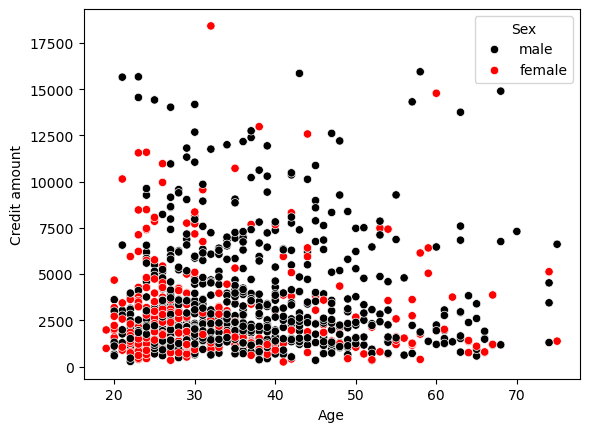

In [14]:
sns.scatterplot(x="Age",y="Credit amount",data=data,palette=["black","red"],hue="Sex")
plt.show()

****
- Histogram

****
- 2.A histogram plot is a type od graph used to show the distribution of numerical data.

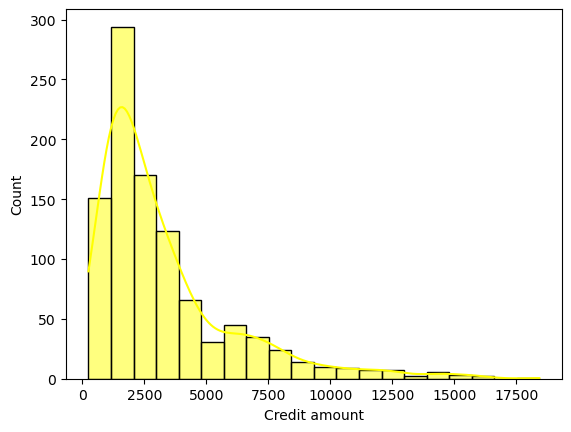

In [15]:
sns.histplot(data["Credit amount"],color="yellow",kde=True,bins=20)
plt.show()

****
-Box Plot

****
- 3. A box plot is a statistical graph used the distribution of numerical data using quartiles.

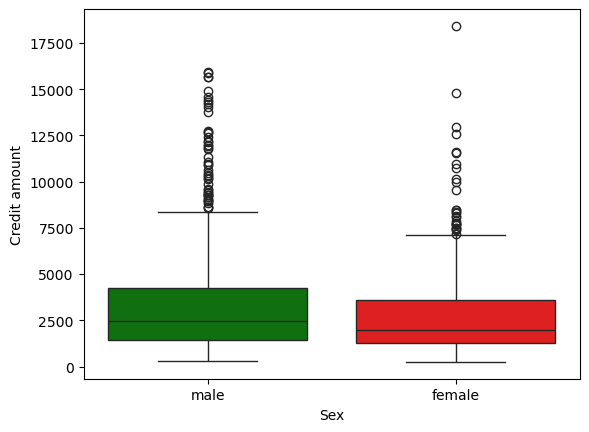

In [16]:
sns.boxplot(x="Sex",y="Credit amount",data=data,palette=["Green","Red"])
plt.show()

****
- Headmap plot

****
- 4.A headmap plot is a type od data visualization that uses colors to represent values in a matrix or table.

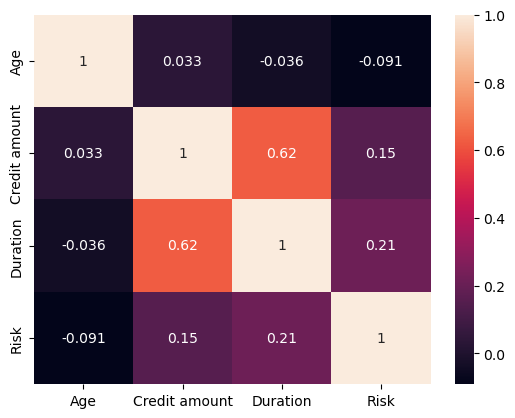

In [17]:
sns.heatmap(data.corr(numeric_only=True),annot=True)
plt.show()

****
- Pair plot

****
- 5.A pair plot is a type of plot that allows you to visualize relationships between all numerical variable in a dataset as once.

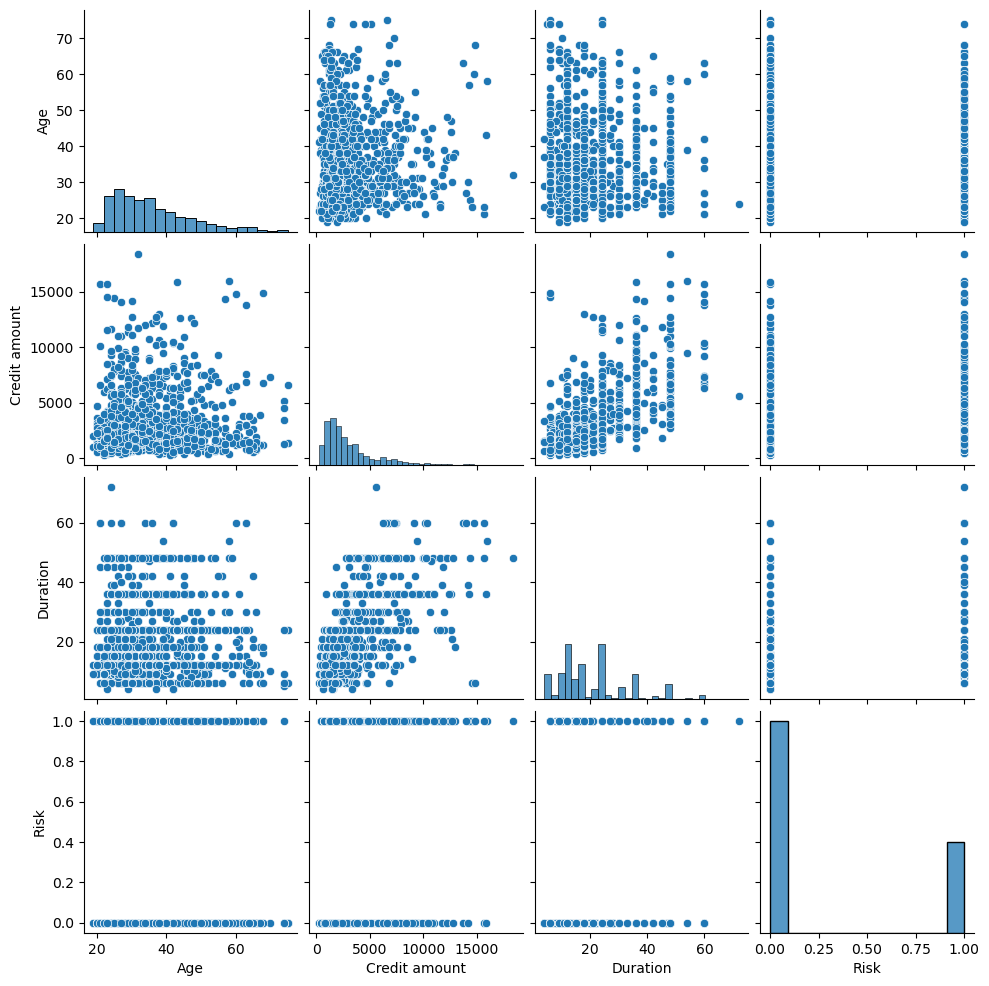

In [18]:
sns.pairplot(data)
plt.show()

****
- Barplot

****
- 6.A bar plot (or bar chart) is a type gragh used to compare categries.

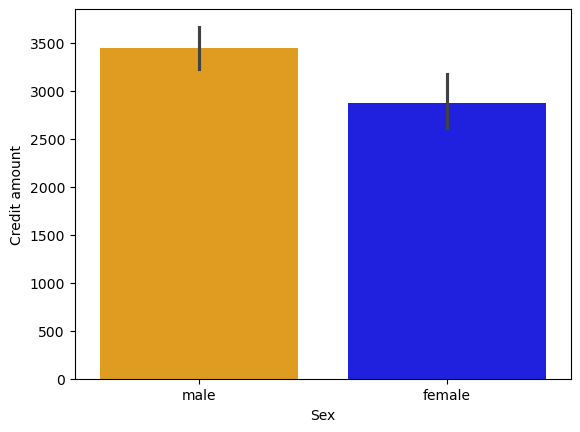

In [19]:
sns.barplot(x="Sex",y="Credit amount",data=data,palette=["Orange","Blue"])
plt.show()

****
- Violin Plot

****
- 7.A violin plot is a type of graph used to visualize the distribution of numerical data,similar to a box plot, but it also shows the density (shape) of the data.

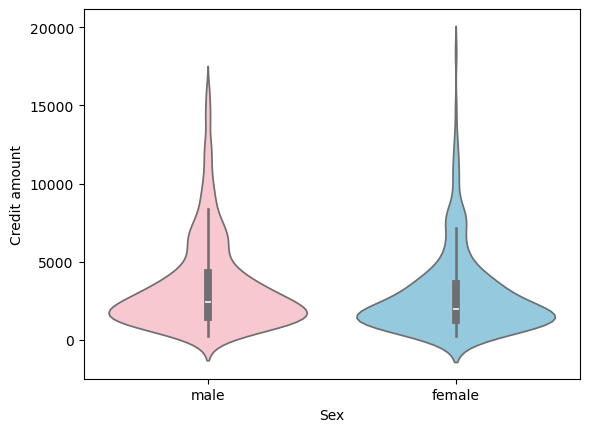

In [20]:
sns.violinplot(x="Sex",y="Credit amount",data=data,palette=["Pink","SkyBlue"])
plt.show()

### Univariate analysis

In [21]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2, 
        sharex=True, 
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,)
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet")  
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2)  
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--") 
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-") 

In [22]:
def labeled_barplot(data, feature, perc=False, n=None):
    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))
    plt.xticks(rotation=90, fontsize=15)
    ax=sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],)
    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total)  
        else:
            label = p.get_height() 
        x = p.get_x() + p.get_width() / 2  
        y = p.get_height()  
        ax.annotate(label,(x, y),ha="center",va="center",size=12,xytext=(0, 5),textcoords="offset points",)  
    plt.show() 

## Observation on Age

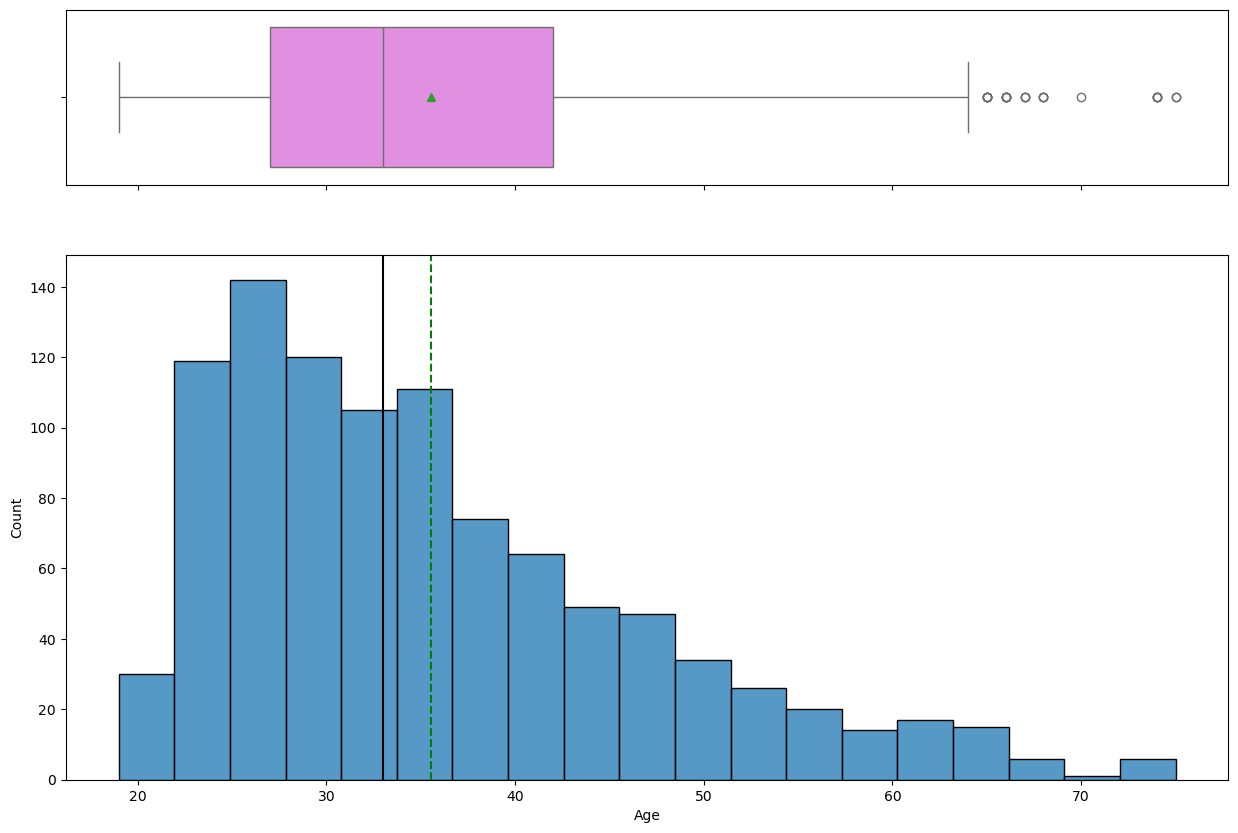

In [23]:
histogram_boxplot(data,"Age")

- The distribution of age is right-skewed
- The boxplot shows that there are outliers at the right end
- We will not treat these outliers as they represent the real market trend

## Observation on Credit Amount

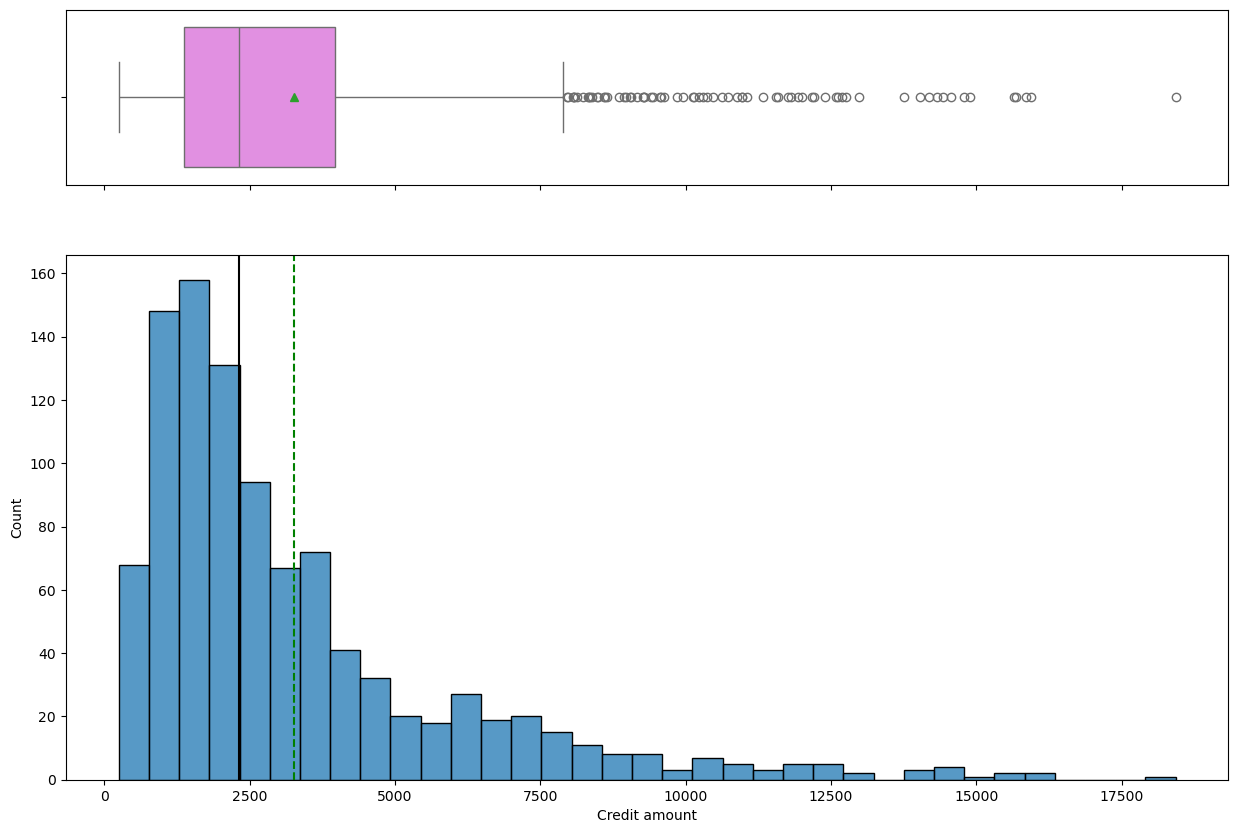

In [24]:
histogram_boxplot(data,"Credit amount")

- The distribution of the credit amount is right-skewed
- The boxplot shows that there are outliers at the right end
- We will not treat these outliers as they represent the real market trend

## Observations on Risk

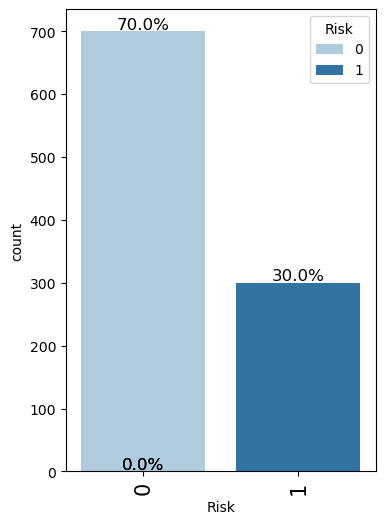

In [25]:
labeled_barplot(data,"Risk",perc=True)

- As mentioned earlier, the class distribution in the target variable is imbalanced.
- We have 70% observations for non-defaulters and 30% observations for defaulters.

## Observations on Sex of Customers

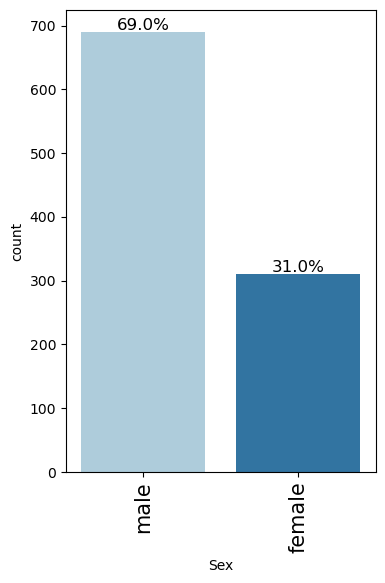

In [26]:
labeled_barplot(data,"Sex",perc=True)

- Male customers are taking more credit than female customers
- There are 69% male customers and 31% female customers

## Data Preprocessing

### Outlier Detection and Treatment

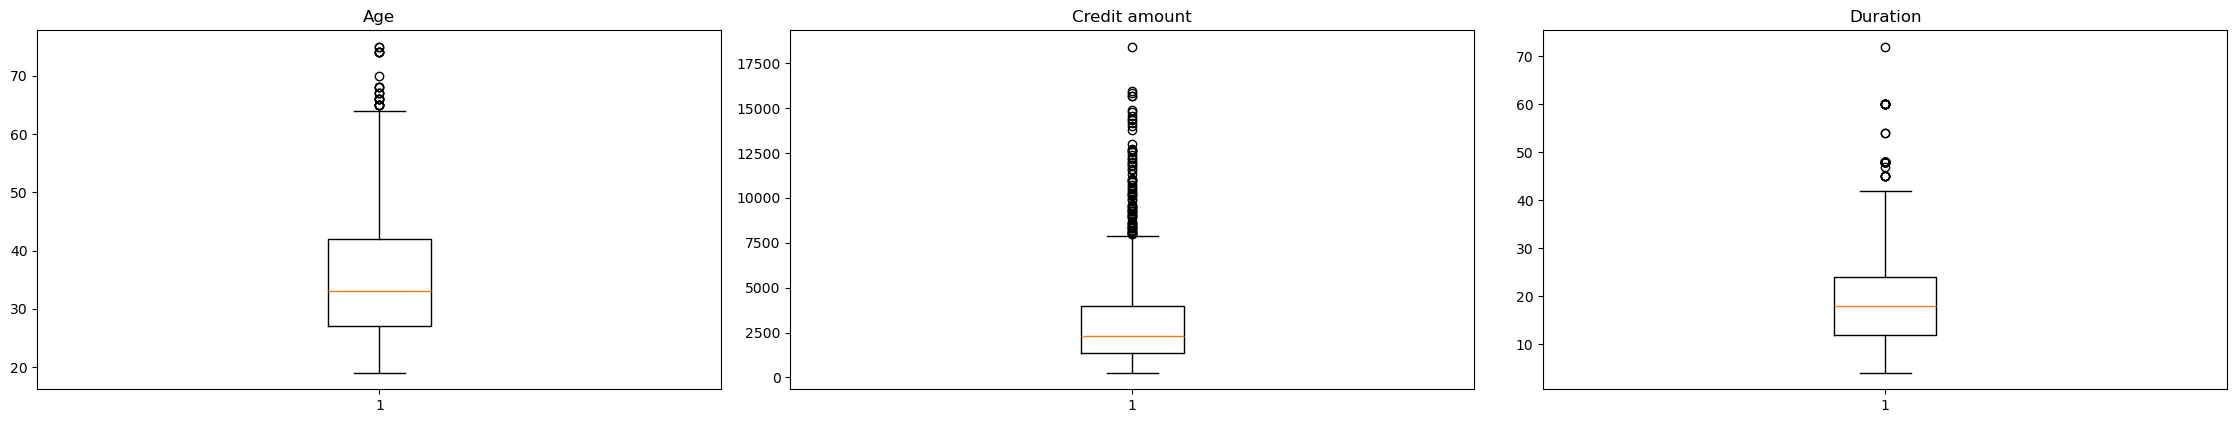

In [27]:
numerical_col = data.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(30, 20))
numerical_col.remove("Risk")

for i, variable in enumerate(numerical_col):
    plt.subplot(5, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

- We will not be treating the outliers since all are genuine values.

In [28]:
numerical_col = data.select_dtypes(include=np.number).columns.tolist()
numerical_col.remove("Risk")

for col in numerical_col:
    
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    data[col] = np.where(data[col] > upper_limit,
                         upper_limit,
                         data[col])
    
    data[col] = np.where(data[col] < lower_limit,
                         lower_limit,
                         data[col])
print("Outliers capped successfully")

Outliers capped successfully


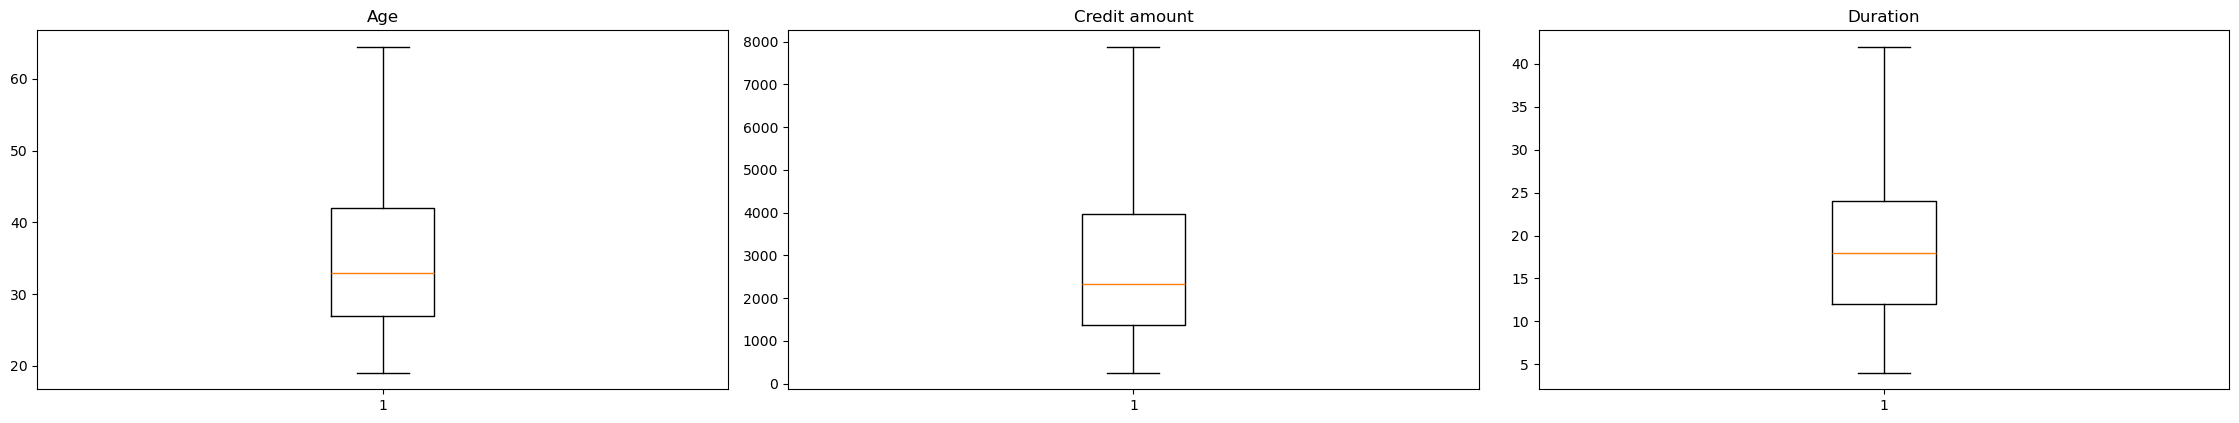

In [29]:
numerical_col = data.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(30, 20))
numerical_col.remove("Risk")

for i, variable in enumerate(numerical_col):
    plt.subplot(5, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

### Data Preparation

In [30]:
data["Duration"] = data["Duration"] / 12

In [31]:
X = data.drop("Risk", axis=1)
Y = data["Risk"]
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1)#, stratify=Y)

In [32]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (700, 16)
Shape of test set :  (300, 16)
Percentage of classes in training set:
Risk
0    0.694286
1    0.305714
Name: proportion, dtype: float64
Percentage of classes in test set:
Risk
0    0.713333
1    0.286667
Name: proportion, dtype: float64


## Model Building

### Model Evaluation Criterion

**Model can make wrong predictions as:**

1. Model predicted a non-defaulter as a defaulter - False Positive
2. Model predicted a defaulter as a non-defaulter - False Negative

In [33]:
def model_performance_classification_sklearn(
    model, predictors, target, threshold=0.5):
    pred_temp = (model.predict_proba(predictors))[:, 1] > threshold
    pred = np.round(pred_temp)
    acc = accuracy_score(target, pred)  
    recall = recall_score(target, pred)  
    precision = precision_score(target, pred)  
    f1 = f1_score(target, pred) 
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],)
    return df_perf

In [34]:
def confusion_matrix_sklearn(model, predictors, target, threshold=0.5):
    pred_temp = (model.predict_proba(predictors))[:, 1] > threshold
    y_pred = np.round(pred_temp)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [ ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()]
    ).reshape(2, 2)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Logistic Regression

In [35]:
model = LogisticRegression(solver="newton-cg", random_state=1)
model.fit(X_train, y_train)

LogisticRegression(random_state=1, solver='newton-cg')

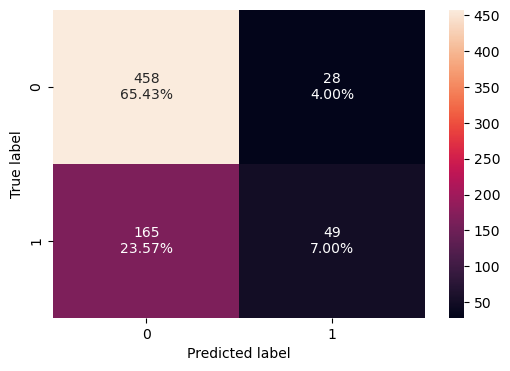

In [36]:
confusion_matrix_sklearn(model, X_train,y_train)

In [42]:
log_reg_model_train_perf = model_performance_classification_sklearn(model, X_train, y_train)
print("Training performance:")
log_reg_model_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.724286,0.228972,0.636364,0.33677


confusion_matrix_sklearn(model, X_test, y_test)

In [44]:
log_reg_model_test_perf = model_performance_classification_sklearn(model, X_test, y_test)
print("Test performance:")
log_reg_model_test_perf

Test performance:


,Accuracy,Recall,Precision,F1
0,0.7,0.186047,0.444444,0.262295


* The model has a low recall and a low precision on the training and test sets.

# Model Performance Improvement

### Optimal Threshold from ROC curve

** Let's first display the ROC curve and compute the ROC-AUC score. **

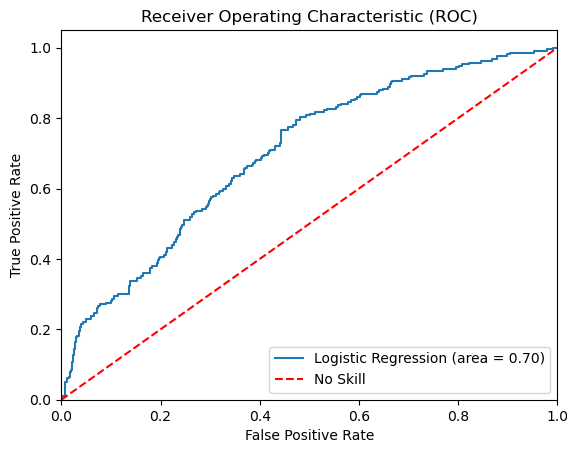

In [45]:
logit_roc_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:,1])
fpr, tpr, thresholds = roc_curve(y_train, model.predict_proba(X_train)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--',label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [46]:
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_auc_roc = thresholds[optimal_idx]
print(optimal_threshold_auc_roc)

0.2687507726290888


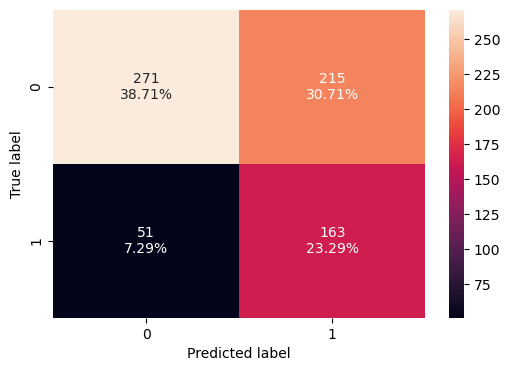

In [47]:
confusion_matrix_sklearn(model, X_train, y_train, threshold=optimal_threshold_auc_roc)

In [49]:
log_reg_model_train_perf_threshold_auc_roc = model_performance_classification_sklearn(model, X_train, y_train, threshold=optimal_threshold_auc_roc)
print("Training performance:")
log_reg_model_train_perf_threshold_auc_roc

Training performance:


,Accuracy,Recall,Precision,F1
0,0.62,0.761682,0.431217,0.550676


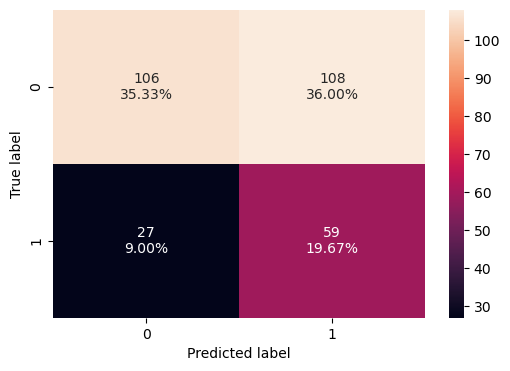

In [50]:
confusion_matrix_sklearn(model, X_test, y_test, threshold=optimal_threshold_auc_roc)

In [51]:
log_reg_model_test_perf_threshold_auc_roc = model_performance_classification_sklearn(model, X_test, y_test, threshold=optimal_threshold_auc_roc)
print("Testing performance:")
log_reg_model_test_perf_threshold_auc_roc

Testing performance:


,Accuracy,Recall,Precision,F1
0,0.55,0.686047,0.353293,0.466403


* Model performance has improved significantly.
* Model is giving a recall of 0.74 as compared to initial model which was giving a recall of 0.2.
* Precision, however, has decreased from 0.59 to 0.35.

### Optimal Threshold from Precision-Recall curve

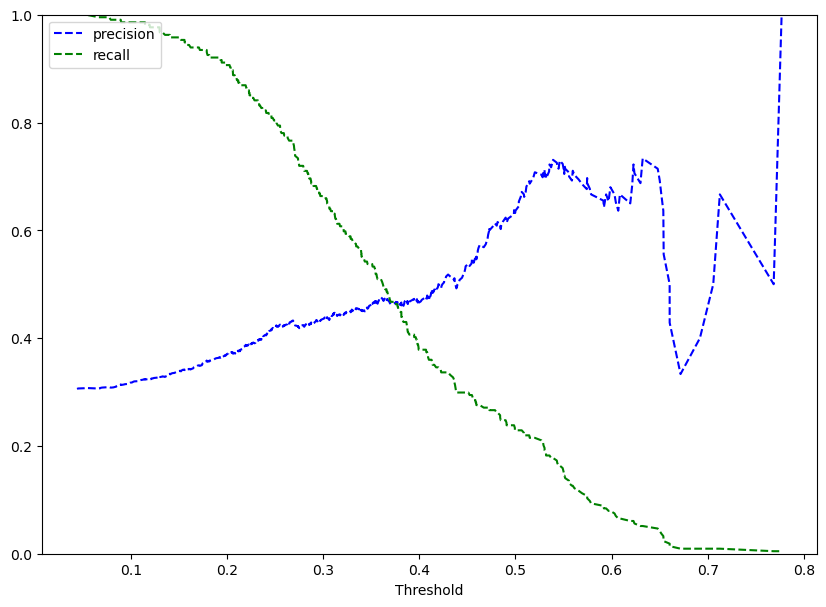

In [54]:
y_scores = model.predict_proba(X_train)[:, 1]
prec, rec, thres = precision_recall_curve(y_train, y_scores,)

def plot_prec_recall_vs_thres(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])


plt.figure(figsize=(10, 7))
plot_prec_recall_vs_thres(prec, rec, thres)
plt.show()

In [55]:
idx = np.where((rec == prec) == True)[0][0]
optimal_threshold_prec_rec = thres[idx]
print(optimal_threshold_prec_rec)

0.3757066408313188


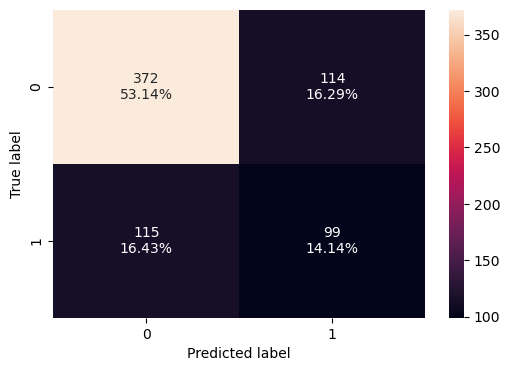

In [61]:
confusion_matrix_sklearn(model, X_train, y_train, threshold=optimal_threshold_prec_rec)

In [57]:
log_reg_model_train_perf_threshold_curve = model_performance_classification_sklearn(model, X_train, y_train, threshold=optimal_threshold_prec_rec)
print("Training performance:")
log_reg_model_train_perf_threshold_curve

Training performance:


,Accuracy,Recall,Precision,F1
0,0.672857,0.462617,0.464789,0.4637


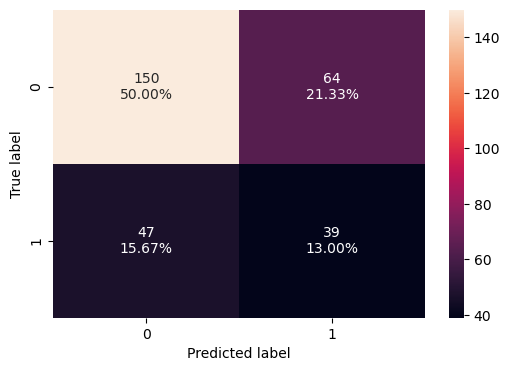

In [58]:
confusion_matrix_sklearn(model, X_test, y_test, threshold=optimal_threshold_prec_rec)

In [60]:
log_reg_model_test_perf_threshold_curve = model_performance_classification_sklearn(model, X_test, y_test, threshold=optimal_threshold_prec_rec)
print("Testing performance:")
log_reg_model_test_perf_threshold_curve

Testing performance:


,Accuracy,Recall,Precision,F1
0,0.63,0.453488,0.378641,0.412698


* Recall has improved as compared to the initial model.
* Model is giving a better performance with 0.25 threshold found using AUC-ROC curve.

In [63]:
models_train_comp_df = pd.concat(
    [
        log_reg_model_train_perf.T,
        log_reg_model_train_perf_threshold_auc_roc.T,
        log_reg_model_train_perf_threshold_curve.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression - default threshold",
    "Logistic Regression - 0.25 threshold",
    "Logistic Regression - 0.36 threshold",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Logistic Regression - default threshold,Logistic Regression - 0.25 threshold,Logistic Regression - 0.36 threshold
Accuracy,0.724286,0.620000,0.672857
Recall,0.228972,0.761682,0.462617
Precision,0.636364,0.431217,0.464789
F1,0.336770,0.550676,0.463700


In [64]:
models_test_comp_df = pd.concat(
    [
        log_reg_model_test_perf.T,
        log_reg_model_test_perf_threshold_auc_roc.T,
        log_reg_model_test_perf_threshold_curve.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Logistic Regression - default threshold",
    "Logistic Regression - 0.25 threshold",
    "Logistic Regression - 0.36 threshold",
]

print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Logistic Regression - default threshold,Logistic Regression - 0.25 threshold,Logistic Regression - 0.36 threshold
Accuracy,0.700000,0.550000,0.630000
Recall,0.186047,0.686047,0.453488
Precision,0.444444,0.353293,0.378641
F1,0.262295,0.466403,0.412698
